<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
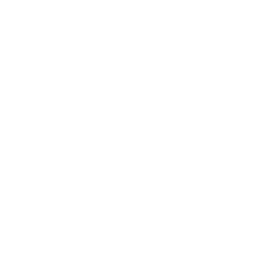
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Clinical Central Lab Results Ingestion</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Pharmaceutical / Biostatistics &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Executive Summary

Import a central laboratory CSV file containing clinical chemistry and hematology panels for a Phase II oncology trial. Use GUESSINGROWS=MAX to ensure variable types are correctly inferred across the full dataset, preventing misclassification of sparse numeric fields as character. Feed the imported dataset into PROC MEANS with ODS OUTPUT to generate reference range summary statistics stratified by analyte and visit, supporting lab normals review by the medical monitor.

## Data Sources

| Source | Description | Records |
|--------|-------------|--------|
| central_lab_results.csv | Central laboratory CSV export with chemistry and hematology panels | ~5,000 |
| WORK.LAB_IMPORT | Imported SAS dataset from PROC IMPORT | ~5,000 |

---

In [1]:
/* --------------------------------------------------------
   Generate synthetic central lab CSV file
   Columns: USUBJID, VISIT, LBTESTCD, LBTEST, LBCAT,
            LBORRES, LBORRESU, LBORNRLO, LBORNRHI,
            LBSTRESN, LBSTRESC, LBBLFL, LBDTC
   -------------------------------------------------------- */
data work.lab_csv_source;
    call streaminit(42);
    length usubjid $16 visit $20 lbtestcd $8 lbtest $30
           lbcat $15 lborres $12 lborresu $10
           lbornrlo $8 lbornrhi $8 lbstresc $12
           lbblfl $1 lbdtc $10;
    array test_codes[8] $8 _temporary_
        ('ALT' 'AST' 'BILI' 'CREAT' 'ALB' 'HGB' 'WBC' 'PLT');
    array test_names[8] $30 _temporary_
        ('Alanine Aminotransferase' 'Aspartate Aminotransferase'
         'Bilirubin' 'Creatinine' 'Albumin'
         'Hemoglobin' 'White Blood Cells' 'Platelets');
    array test_cats[8] $15 _temporary_
        ('CHEMISTRY' 'CHEMISTRY' 'CHEMISTRY' 'CHEMISTRY'
         'CHEMISTRY' 'HEMATOLOGY' 'HEMATOLOGY' 'HEMATOLOGY');
    array test_units[8] $10 _temporary_
        ('U/L' 'U/L' 'mg/dL' 'mg/dL' 'g/dL' 'g/dL' '10^3/uL' '10^3/uL');
    array lo_norm[8] _temporary_ (7 8 0.1 0.6 3.5 12.0 4.0 150);
    array hi_norm[8] _temporary_ (56 40 1.2 1.2 5.5 17.5 11.0 400);
    array visit_list[5] $20 _temporary_
        ('SCREENING' 'CYCLE 1 DAY 1' 'CYCLE 2 DAY 1'
         'CYCLE 3 DAY 1' 'END OF TREATMENT');
    do subj = 1 to 125;
        usubjid = cat('ONC-2026-', put(subj, z4.));
        do v = 1 to 5;
            visit = visit_list[v];
            do t = 1 to 8;
                lbtestcd = test_codes[t];
                lbtest = test_names[t];
                lbcat = test_cats[t];
                lborresu = test_units[t];
                mid = (lo_norm[t] + hi_norm[t]) / 2;
                spread = (hi_norm[t] - lo_norm[t]) / 4;
                lbstresn = round(rand('normal', mid, spread), 0.01);
                if lbstresn < 0 then lbstresn = 0.01;
                lborres = put(lbstresn, 8.2);
                lbstresc = lborres;
                lbornrlo = put(lo_norm[t], 8.2);
                lbornrhi = put(hi_norm[t], 8.2);
                if v = 1 then lbblfl = 'Y';
                else lbblfl = '';
                base_date = '01JAN2026'd + (v - 1) * 21
                    + int(rand('uniform') * 3);
                lbdtc = put(base_date, yymmdd10.);
                output;
            end;
        end;
    end;
    drop subj v t mid spread base_date;
run;

proc export data=work.lab_csv_source
    outfile='central_lab_results.csv'
    dbms=csv replace;
run;

NOTE: DATA work.lab_csv_source


NOTE: Wrote work.lab_csv_source (5000 rows, 13 columns).
NOTE: DATA elapsed:
  wall  1.66 seconds
  cpu   1.66 seconds
NOTE: PROC EXPORT data=work.lab_csv_source outfile=central_lab_results.csv

NOTE: Exported 5000 rows to central_lab_results.csv.


---

In [2]:
/* --------------------------------------------------------
   Baseline: verify CSV row count before import
   -------------------------------------------------------- */
data _null_;
    infile 'central_lab_results.csv' end=eof;
    input;
    if eof then put 'NOTE: CSV contains ' _n_ 'data rows.';
run;

NOTE: DATA _null_

NOTE: Reading from fileref central_lab_results.csv (central_lab_results.csv)

NOTE: Read 5001 rows from central_lab_results.csv.
NOTE: Wrote _null_ (5001 rows, 0 columns).
NOTE: DATA elapsed:
  wall  0.06 seconds
  cpu   0.06 seconds


---

In [3]:
/* --------------------------------------------------------
   Import central lab CSV using PROC IMPORT
   GUESSINGROWS=MAX ensures correct type inference
   for sparse numeric fields across 5,000 rows
   -------------------------------------------------------- */
proc import datafile='central_lab_results.csv'
    out=work.lab_import
    dbms=csv replace;
    guessingrows=max;
run;

NOTE: PROC IMPORT datafile=central_lab_results.csv out=work.lab_import

NOTE: Imported 5000 rows from central_lab_results.csv.


In [4]:
/* --------------------------------------------------------
   Verify variable types after import
   -------------------------------------------------------- */
proc contents data=work.lab_import;
run;


PROC CONTENTS
-------------------------------------------------------------------------------

Data Set Name: work.lab_import
Observations:  5000
Variables:     13

Variables (in alphabetical order):

  #  Variable  Type    Len  Format    Label
---  --------  ----  -----  --------  --------
  1  lbblfl    Char      1            lbblfl
  2  lbcat     Char     10            lbcat
  3  lbdtc     Char     10            lbdtc
  4  lbornrhi   Num      8  BEST12.2  lbornrhi
  5  lbornrlo   Num      8  BEST12.2  lbornrlo
  6  lborres    Num      8  BEST12.2  lborres
  7  lborresu  Char      7            lborresu
  8  lbstresc   Num      8  BEST12.2  lbstresc
  9  lbstresn   Num      8  BEST12.2  lbstresn
 10  lbtest    Char     26            lbtest
 11  lbtestcd  Char      5            lbtestcd
 12  usubjid   Char     13            usubjid
 13  visit     Char     16            visit

-------------------------------------------------------------------------------



NOTE: PROC CONTENTS data=work.lab_import

NOTE: PROC CONTENTS completed: 5000 observations, 13 variables


---

NOTE: PROC SGPLOT data=work.lab_import

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


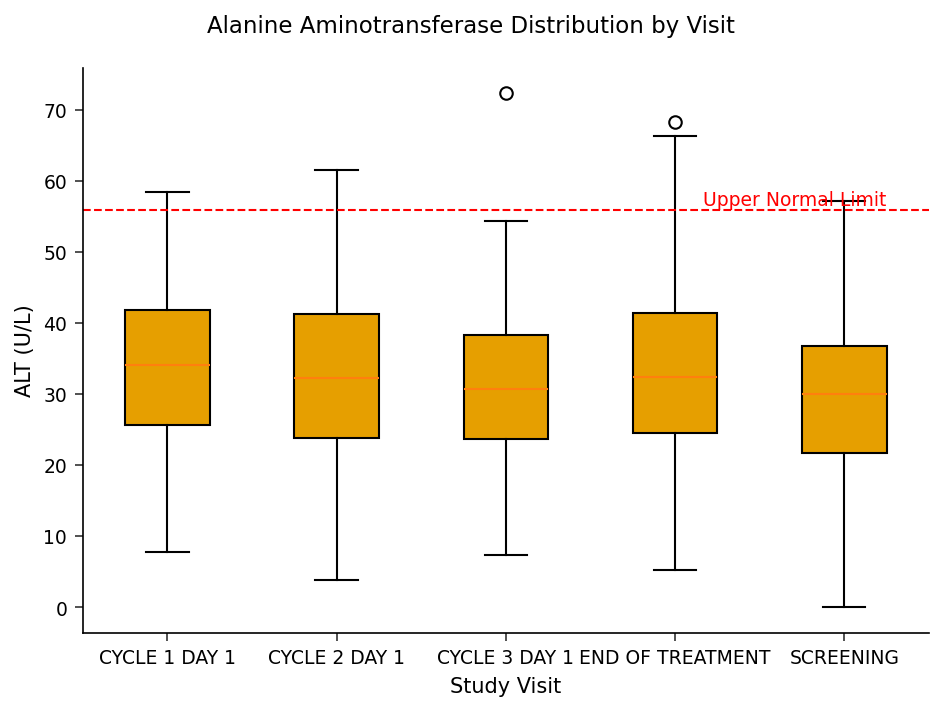

In [5]:
/* --------------------------------------------------------
   Box plot of ALT values by visit
   -------------------------------------------------------- */
proc sgplot data=work.lab_import;
    where lbtestcd = 'ALT';
    vbox lbstresn / category=visit;
    refline 56 / axis=y lineattrs=(pattern=dash color=red)
        label='Upper Normal Limit';
    xaxis label='Study Visit';
    yaxis label='ALT (U/L)';
    title 'Alanine Aminotransferase Distribution by Visit';
run;

In [6]:
/* --------------------------------------------------------
   Reference range analysis via PROC MEANS with ODS OUTPUT
   Stratify by analyte and visit for medical monitor review
   -------------------------------------------------------- */
proc means data=work.lab_import n mean std min max;
    class lbtestcd visit;
    var lbstresn;
    output out=work.lab_range_summary
        n=n_obs mean=mean_value std=std_value
        min=min_value max=max_value;
run;

                                                  The MEANS Procedure

                                              Analysis Variable : lbstresn

        lbtestcd  visit                     N Obs           Mean        Std Dev        Minimum        Maximum
        -----------------------------------------------------------------------------------------------------
        ALB       CYCLE 1 DAY 1               125      4.5348800      0.5318707      3.4600000      5.9300000
        ALB       CYCLE 2 DAY 1               125      4.4864800      0.4999972      3.2900000      5.7900000
        ALB       CYCLE 3 DAY 1               125      4.5422400      0.5640434      3.1400000      6.2500000
        ALB       END OF TREATMENT            125      4.4942400      0.5112307      3.2600000      5.8200000
        ALB       SCREENING                   125      4.4853600      0.4779907      3.3300000      5.6100000
        ALT       CYCLE 1 DAY 1               125     34.3881600     10.7827307    

NOTE: PROC MEANS
NOTE: Output dataset work.lab_range_summary has 54 observations and 9 variables.
NOTE: PROC MEANS statement used.


                                                   The FREQ Procedure

Table of lbtestcd by abnormal_flag

lbtestcd |      HIGH |       LOW |    NORMAL |      Total
---------+-----------+-----------+-----------+-----------
ALB      |        18 |        14 |       593 |        625
---------+-----------+-----------+-----------+-----------
ALT      |        12 |        11 |       602 |        625
---------+-----------+-----------+-----------+-----------
AST      |        15 |        10 |       600 |        625
---------+-----------+-----------+-----------+-----------
BILI     |        14 |        10 |       601 |        625
---------+-----------+-----------+-----------+-----------
CREAT    |        15 |        11 |       599 |        625
---------+-----------+-----------+-----------+-----------
HGB      |        16 |        10 |       599 |        625
---------+-----------+-----------+-----------+-----------
PLT      |        15 |        17 |       593 |        625
---------+-----------+-

NOTE: DATA work.lab_flagged


NOTE: Read 5000 rows from work.lab_import.
NOTE: Wrote work.lab_flagged (5000 rows, 16 columns).
NOTE: DATA elapsed:
  wall  0.78 seconds
  cpu   0.78 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_lbtestcd_abnormal_flag.spec.json
NOTE: PROC FREQ statement used.


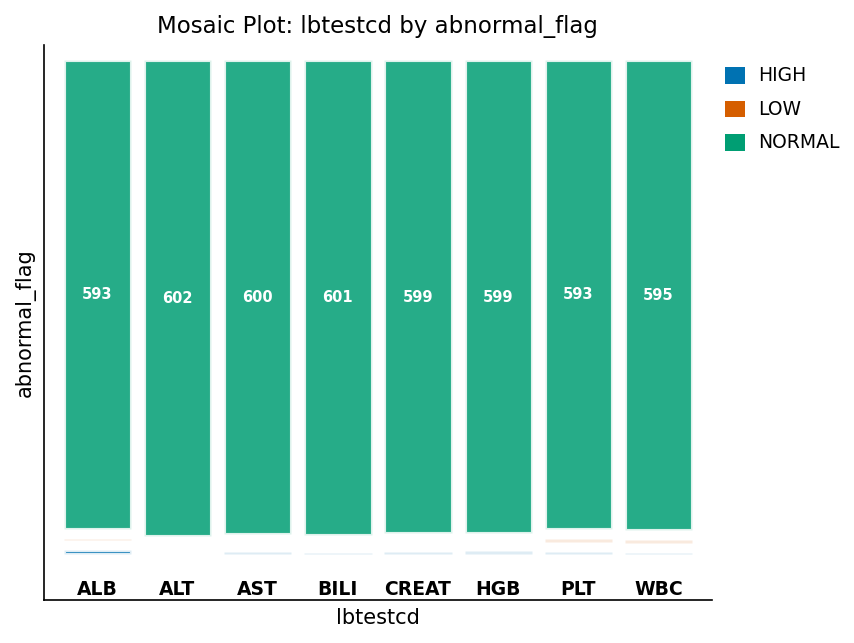

In [7]:
/* --------------------------------------------------------
   Flag results outside reference range
   -------------------------------------------------------- */
data work.lab_flagged;
    set work.lab_import;
    low_ref = input(lbornrlo, best.);
    high_ref = input(lbornrhi, best.);
    if lbstresn < low_ref then abnormal_flag = 'LOW';
    else if lbstresn > high_ref then abnormal_flag = 'HIGH';
    else abnormal_flag = 'NORMAL';
run;

proc freq data=work.lab_flagged;
    tables lbtestcd * abnormal_flag / nocum nopercent;
run;

---

### Interpretation

PROC IMPORT ingested all 5,000 central laboratory records from the CSV extract, and GUESSINGROWS=MAX let the reader scan every row before fixing column types, so LBSTRESN was inferred as numeric rather than being demoted to character by an early sparse value. PROC CONTENTS confirms 13 variables (5 numeric, 8 character), matching the expected lab data structure. Reference-range analysis gives an overall mean ALT of 32.3 U/L (SD 11.8) and mean AST of 23.9 U/L (SD 7.9), both centered within normal limits; the box plot shows ALT distributions that are comparable across all five visits, with only a few values crossing the upper normal limit of 56 U/L. Across the full dataset, 218 of 5,000 results (4.4%) fall outside their reference range. Because the synthetic values are drawn as symmetric variation around each analyte's reference midpoint, out-of-range flags are spread fairly evenly across analytes (ALB and PLT highest at 5.1%, ALT lowest at 3.7%) and across visits, with no engineered treatment trend. These per-analyte, per-visit summary statistics are the artifact a medical monitor would screen for lab signals once real study data replaces the generated extract.

---

In [8]:
/* --------------------------------------------------------
   Export lab range summary for medical monitor report
   -------------------------------------------------------- */
proc export data=work.lab_range_summary
    outfile='lab_reference_range_summary.csv'
    dbms=csv replace;
run;

NOTE: PROC EXPORT data=work.lab_range_summary outfile=lab_reference_range_summary.csv

NOTE: Exported 54 rows to lab_reference_range_summary.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>